<h1>Divisão do dataset: Treino, Teste e Validação.</h1>

In [ ]:
import numpy as np
from pathlib import Path

In [3]:
structures: list[Path] = list(Path('/home/jvc/ZnO_database/data/LDA_xsf_structures').iterdir())

print(f"Total Structures: {len(structures)}")
print('Examples:\t')


for i, struc in enumerate(structures[:10]):
    print(i, struc)


Total Structures: 6254
Examples:	
0 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-1657.xsf
1 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-0539.xsf
2 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-2478.xsf
3 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-1124.xsf
4 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-0150.xsf
5 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-4377.xsf
6 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-2807.xsf
7 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-1231.xsf
8 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-0526.xsf
9 /home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-5554.xsf


In [4]:
# Separa treino, teste e validação. (64%, 20%, 16%)
num_structures = len(structures)

training_percent = 0.64
test_percent = 0.20
validation_percent = 0.16

training_size = np.ceil(num_structures * training_percent).astype(int)
test_size = np.floor(num_structures * test_percent).astype(int)
validation_size = np.floor(num_structures * validation_percent).astype(int)


In [7]:
print(f"Tamanho da base: {num_structures}\n")
print(f"{'Conjunto':<15}{'Percentual':>12}{'Tamanho':>15}")
print("-" * 42)
print(f"{'Train':<15}{f'{training_percent:.1%}':>12}{training_size:>15}")
print(f"{'Test':<15}{f'{test_percent:.1%}':>12}{test_size:>15}")
print(f"{'Validation':<15}{f'{validation_percent:.1%}':>12}{validation_size:>15}\n")
print(f"{training_size + test_size + validation_size = }")
print(f"{training_size + test_size = }")

Tamanho da base: 6254

Conjunto         Percentual        Tamanho
------------------------------------------
Train                 64.0%           4003
Test                  20.0%           1250
Validation            16.0%           1000

training_size + test_size + validation_size = 6253
training_size + test_size = 5253


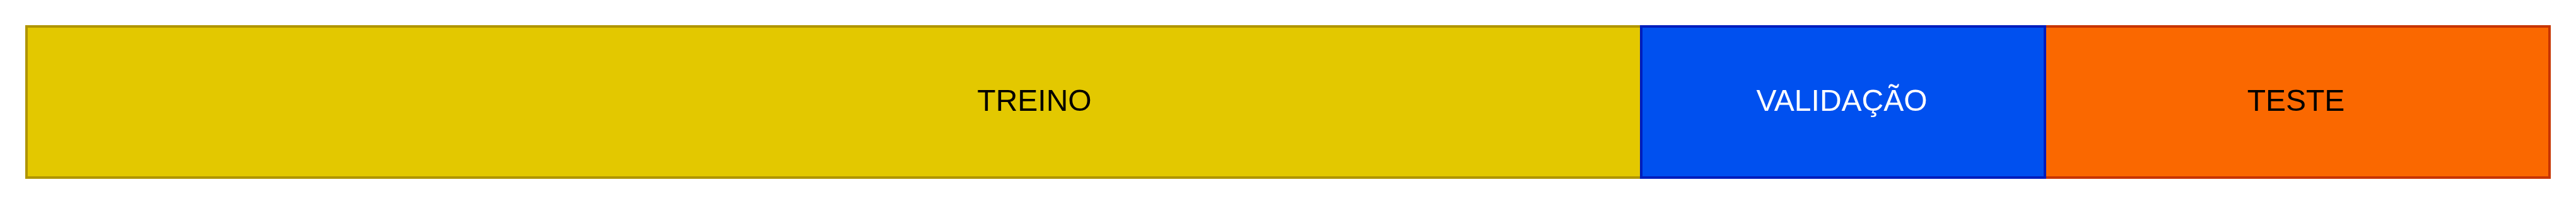

In [8]:
structures

[PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-1657.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-0539.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-2478.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-1124.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-0150.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-4377.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-2807.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-1231.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-0526.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-5554.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-1419.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-0368.xsf'),
 PosixPath('/home/jvc/ZnO_database/data/LDA_xsf_structures/LDA-2650.xsf'),
 PosixPath('/home/jvc/ZnO

In [10]:
import shutil

# Training and Test Structures will be seen by aenet, so I choose
# a list of structures that will not be seen to validation (predict.x), and all the rest
# you be used for aenet's calculations.


# aenet_structures : treino + validação => 80%
# test_structures : test => 20%
test_structures: list[Path] = np.random.choice(
    structures, size=test_size, replace=False
)


# Escolher todas as estruturas, menos as de validação.
aenet_structures = set(structures) - set(test_structures)

# Create directories
outdirs = {
    "aenet_structures": Path("LDA_training_set"),
    "test_structures": Path("LDA_test_set"),
}

for outdir in outdirs.values():
    outdir.mkdir(exist_ok=True)

# Copy selected structures to respectively directory
for file in aenet_structures:
    shutil.copy(src=file, dst=outdirs["aenet_structures"])

for file in test_structures:
    shutil.copy(src=file, dst=outdirs["test_structures"])